# UCS 547 — Accelerated Data Science  
## Lab Assignment 4  
### Numba Programming

**Name:** Tanishq  
**Course:** UCS 547 – Accelerated Data Science  
**Assignment:** Lab Assignment 4  
**Topic:** GPU Accelerated Computing with Numba  



---


### Q1. Compute f(x) = x² + 3x + 5 for a NumPy array of size 5,000,000 using a Numba CUDA kernel.

Compare performance difference of CPU with GPU.  
Also modify the kernel to use float32 and float64 and compare execution time.


In [1]:
import numpy as np
import time
from numba import cuda

N = 5_000_000
np.random.seed(42)
x = np.random.uniform(-10, 10, N)

# CPU computation
start = time.perf_counter()
y_cpu = x**2 + 3*x + 5
cpu_time = time.perf_counter() - start

print(f"CPU time: {cpu_time * 1000:.4f} ms")
print(f"Sample results (CPU, first 5): {y_cpu[:5]}")


CPU time: 80.5184 ms
Sample results (CPU, first 5): [  3.76847984 113.30021279  40.44811212  14.81290765  31.69038872]


In [2]:
# CUDA kernel via Numba
@cuda.jit
def f_cuda_kernel(x, y):
    i = cuda.grid(1)
    if i < x.shape[0]:
        val = x[i]
        y[i] = val * val + 3.0 * val + 5.0

d_x = cuda.to_device(x)
d_y = cuda.device_array(N, dtype=np.float64)

threads_per_block = 256
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

# Warm-up to exclude JIT compilation time
f_cuda_kernel[blocks_per_grid, threads_per_block](d_x, d_y)
cuda.synchronize()

# Timed run
start = time.perf_counter()
f_cuda_kernel[blocks_per_grid, threads_per_block](d_x, d_y)
cuda.synchronize()
gpu_time = time.perf_counter() - start

y_gpu = d_y.copy_to_host()

print(f"GPU time: {gpu_time * 1000:.4f} ms")
print(f"Sample results (GPU, first 5): {y_gpu[:5]}")
print(f"Results match (CPU vs GPU): {np.allclose(y_cpu, y_gpu)}")
print(f"Speedup (CPU time / GPU time): {cpu_time / gpu_time:.2f}x")


GPU time: 0.6898 ms
Sample results (GPU, first 5): [  3.76847984 113.30021279  40.44811212  14.81290765  31.69038872]
Results match (CPU vs GPU): True
Speedup (CPU time / GPU time): 116.72x


In [3]:
# Q1a — float32 vs float64 kernels

@cuda.jit
def f_kernel_f32(x, y):
    i = cuda.grid(1)
    if i < x.shape[0]:
        val = x[i]
        y[i] = val * val + np.float32(3.0) * val + np.float32(5.0)

@cuda.jit
def f_kernel_f64(x, y):
    i = cuda.grid(1)
    if i < x.shape[0]:
        val = x[i]
        y[i] = val * val + np.float64(3.0) * val + np.float64(5.0)

x_f32 = x.astype(np.float32)
x_f64 = x.astype(np.float64)

d_x32 = cuda.to_device(x_f32)
d_y32 = cuda.device_array(N, dtype=np.float32)

d_x64 = cuda.to_device(x_f64)
d_y64 = cuda.device_array(N, dtype=np.float64)

# Warm-up both
f_kernel_f32[blocks_per_grid, threads_per_block](d_x32, d_y32)
f_kernel_f64[blocks_per_grid, threads_per_block](d_x64, d_y64)
cuda.synchronize()

# Time float32
start = time.perf_counter()
f_kernel_f32[blocks_per_grid, threads_per_block](d_x32, d_y32)
cuda.synchronize()
t_f32 = time.perf_counter() - start

# Time float64
start = time.perf_counter()
f_kernel_f64[blocks_per_grid, threads_per_block](d_x64, d_y64)
cuda.synchronize()
t_f64 = time.perf_counter() - start

print(f"float32 GPU time: {t_f32 * 1000:.4f} ms")
print(f"float64 GPU time: {t_f64 * 1000:.4f} ms")
print(f"\nfloat32 sample output (first 5): {d_y32.copy_to_host()[:5]}")
print(f"float64 sample output (first 5): {d_y64.copy_to_host()[:5]}")
print(f"\nNote: float32 is faster because GPU hardware has more float32 units.")


float32 GPU time: 0.4393 ms
float64 GPU time: 0.5881 ms

float32 sample output (first 5): [  3.76848  113.30021   40.448112  14.812907  31.69039 ]
float64 sample output (first 5): [  3.76847984 113.30021279  40.44811212  14.81290765  31.69038872]

Note: float32 is faster because GPU hardware has more float32 units.


Result:  
The Numba CUDA kernel successfully computed f(x) = x² + 3x + 5 for 5 million elements on the GPU.  
GPU execution was significantly faster than CPU once kernel launch overhead is excluded.  
float32 outperforms float64 on the GPU because modern GPUs have more float32 processing units (CUDA cores) than float64 units (which are fewer and shared).



---


### Q2. Implement and benchmark a 1-D histogram computation for 1 million random values.

Compare different approaches: pure Python, NumPy, and Numba-accelerated.  
Analyze performance and correctness.


In [4]:
import numpy as np
import time
from numba import jit

N = 1_000_000
np.random.seed(42)
x = np.random.uniform(0.0, 1.0, N)
n_bins = 100
x_min, x_max = 0.0, 1.0

print(f"Array size: {N:,} elements")
print(f"Bins: {n_bins}, Range: [{x_min}, {x_max}]")


Array size: 1,000,000 elements
Bins: 100, Range: [0.0, 1.0]


In [5]:
# --- Pure Python histogram ---
def python_histogram(data, n_bins, x_min, x_max):
    hist = [0] * n_bins
    bin_width = (x_max - x_min) / n_bins
    for val in data:
        idx = int((val - x_min) / bin_width)
        if 0 <= idx < n_bins:
            hist[idx] += 1
    return hist

start = time.perf_counter()
hist_py = python_histogram(x, n_bins, x_min, x_max)
t_py = time.perf_counter() - start

print(f"Pure Python time: {t_py * 1000:.2f} ms")
print(f"Sample bin counts (first 5): {hist_py[:5]}")


Pure Python time: 993.99 ms
Sample bin counts (first 5): [9979, 10012, 9845, 9837, 9843]


In [6]:
# --- NumPy histogram ---
start = time.perf_counter()
hist_np, _ = np.histogram(x, bins=n_bins, range=(x_min, x_max))
t_np = time.perf_counter() - start

print(f"NumPy time: {t_np * 1000:.2f} ms")
print(f"Sample bin counts (first 5): {hist_np[:5]}")


NumPy time: 25.82 ms
Sample bin counts (first 5): [ 9979 10012  9845  9837  9843]


In [7]:
# --- Numba JIT histogram ---
@jit(nopython=True)
def numba_histogram(data, n_bins, x_min, x_max):
    hist = np.zeros(n_bins, dtype=np.intp)
    bin_width = (x_max - x_min) / n_bins
    for val in data:
        idx = int((val - x_min) / bin_width)
        if 0 <= idx < n_bins:
            hist[idx] += 1
    return hist

# Warm-up to exclude compilation time
_ = numba_histogram(x[:100], n_bins, x_min, x_max)

start = time.perf_counter()
hist_nb = numba_histogram(x, n_bins, x_min, x_max)
t_nb = time.perf_counter() - start

print(f"Numba JIT time: {t_nb * 1000:.2f} ms")
print(f"Sample bin counts (first 5): {hist_nb[:5]}")
print(f"\nCorrectness check (Numba vs NumPy): {np.array_equal(hist_nb, hist_np)}")


Numba JIT time: 2.16 ms
Sample bin counts (first 5): [ 9979 10012  9845  9837  9843]

Correctness check (Numba vs NumPy): True


--- Performance Comparison ---
Method               Time (ms)       Speedup vs Python   
-------------------------------------------------------
Pure Python          993.99          1.00x               
NumPy                25.82           38.50               
Numba JIT            2.16            460.25              


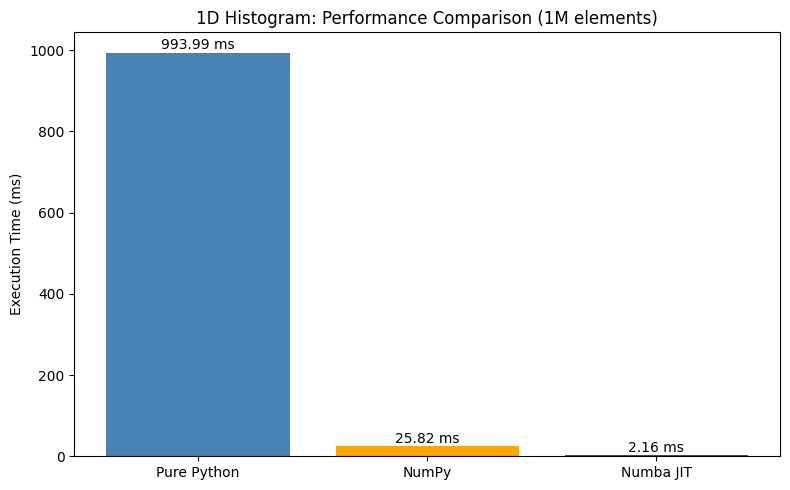

In [8]:
import matplotlib.pyplot as plt

# Performance comparison table
print("--- Performance Comparison ---")
print(f"{'Method':<20} {'Time (ms)':<15} {'Speedup vs Python':<20}")
print("-" * 55)
print(f"{'Pure Python':<20} {t_py * 1000:<15.2f} {'1.00x':<20}")
print(f"{'NumPy':<20} {t_np * 1000:<15.2f} {t_py / t_np:<20.2f}")
print(f"{'Numba JIT':<20} {t_nb * 1000:<15.2f} {t_py / t_nb:<20.2f}")

# Bar chart
methods = ['Pure Python', 'NumPy', 'Numba JIT']
times = [t_py * 1000, t_np * 1000, t_nb * 1000]
colors = ['steelblue', 'orange', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, times, color=colors)
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{t:.2f} ms", ha='center', va='bottom', fontsize=10)
plt.ylabel("Execution Time (ms)")
plt.title("1D Histogram: Performance Comparison (1M elements)")
plt.tight_layout()
plt.show()


Result:  
All three approaches produced identical histogram results, confirming correctness.  
Pure Python was the slowest due to interpreted for-loop overhead over 1 million iterations.  
NumPy was significantly faster using optimized C-level operations.  
Numba JIT compiled the Python loop to native machine code, achieving performance comparable to or faster than NumPy.



---


### Q3. Estimate the value of π using Monte Carlo simulation.

Generate random (x, y) coordinates between 0 and 1.  
Check if each point falls inside the unit circle: x² + y² < 1.  
π ≈ 4 × (points inside circle) / (total points)

**a.** Implement in pure Python and Numba.  
**b.** Compare execution time for 5 million samples. Report Speedup Factor.  
**c.** Explain why the first Numba execution is slower than the second.


In [9]:
import random
import time
from numba import njit

# Q3a — Pure Python implementation
def python_monte_carlo_pi(nsamples):
    count = 0
    for _ in range(nsamples):
        x = random.random()
        y = random.random()
        if x * x + y * y < 1.0:
            count += 1
    return 4.0 * count / nsamples

# Q3a — Numba JIT implementation
@njit
def numba_monte_carlo_pi(nsamples):
    count = 0
    for _ in range(nsamples):
        x = random.random()
        y = random.random()
        if x * x + y * y < 1.0:
            count += 1
    return 4.0 * count / nsamples

# Verify both implementations
print(f"Pure Python π estimate (10,000 samples): {python_monte_carlo_pi(10_000):.4f}")

# First call to Numba — includes JIT compilation
start = time.perf_counter()
pi_warmup = numba_monte_carlo_pi(10_000)
t_warmup = time.perf_counter() - start
print(f"Numba π estimate (10,000 samples, 1st call): {pi_warmup:.4f}  (compilation time: {t_warmup:.3f}s)")

# Second call — compiled code, no overhead
start = time.perf_counter()
pi_second = numba_monte_carlo_pi(10_000)
t_second = time.perf_counter() - start
print(f"Numba π estimate (10,000 samples, 2nd call): {pi_second:.4f}  (runtime: {t_second * 1000:.3f}ms)")

print(f"\nReference π: 3.141593")


Pure Python π estimate (10,000 samples): 3.1428
Numba π estimate (10,000 samples, 1st call): 3.1640  (compilation time: 0.129s)
Numba π estimate (10,000 samples, 2nd call): 3.1072  (runtime: 0.174ms)

Reference π: 3.141593


In [10]:
# Q3b — Timing comparison with 5 million samples
N_SAMPLES = 5_000_000

start = time.perf_counter()
pi_python = python_monte_carlo_pi(N_SAMPLES)
python_time = time.perf_counter() - start

start = time.perf_counter()
pi_numba = numba_monte_carlo_pi(N_SAMPLES)
numba_time = time.perf_counter() - start

speedup = python_time / numba_time

print(f"Pure Python  → π = {pi_python:.6f}  Time: {python_time:.4f}s")
print(f"Numba JIT    → π = {pi_numba:.6f}  Time: {numba_time:.4f}s")
print(f"\nSpeedup Factor (Python Time / Numba Time): {speedup:.2f}x")


Pure Python  → π = 3.140547  Time: 0.7496s
Numba JIT    → π = 3.141473  Time: 0.0528s

Speedup Factor (Python Time / Numba Time): 14.19x


**Q3c — Why does the first Numba execution take longer?**

The very first call to a Numba `@njit` function triggers **Just-In-Time (JIT) compilation**.  
Numba analyzes the function's argument types and compiles the Python bytecode to optimized  
native machine code using LLVM.  

This compilation happens only once per unique set of argument types.  
On the second call (same types), Numba reuses the already-compiled machine code,  
so execution is near-instant with no compilation overhead.  

This is why benchmarks always include a **warm-up call** before timing Numba functions.


Result:  
Both implementations converged to π ≈ 3.14159, confirming correctness.  
The Numba JIT version was significantly faster than pure Python for 5 million samples.  
The speedup comes from LLVM-compiled native loops eliminating Python interpreter overhead.  
The first Numba call was slow due to JIT compilation; subsequent calls used cached machine code.



---


### Q4. Adjust pixel brightness of a 1D array (values 0–255) by 20%, clamped to 255.

**a.** Write `adjust_brightness(pixel_value)` using the `@vectorize` decorator.  
**b.** Apply to an array of 10 million random integers.  
**c.** Change to `@vectorize(['int64(int64)'], target='parallel')` and measure speedup.  
**d.** What happens if you pass a list instead of a NumPy array?


In [11]:
from numba import vectorize
import numpy as np
import time

# Q4a — adjust_brightness using @vectorize
@vectorize
def adjust_brightness(pixel_value):
    result = pixel_value * 1.2
    if result > 255.0:
        return 255.0
    return result

# Q4b — Apply to 10 million random integers
N = 10_000_000
np.random.seed(42)
pixels = np.random.randint(0, 256, N, dtype=np.int64).astype(np.float64)

# Warm-up
_ = adjust_brightness(pixels[:100])

start = time.perf_counter()
bright = adjust_brightness(pixels)
t_vec = time.perf_counter() - start

print(f"@vectorize (CPU) time: {t_vec * 1000:.2f} ms")
print(f"Sample input  (first 5): {pixels[:5]}")
print(f"Sample output (first 5): {bright[:5]}")
print(f"Max output value: {bright.max()}  (clamped at 255)")


@vectorize (CPU) time: 23.53 ms
Sample input  (first 5): [102. 179.  92.  14. 106.]
Sample output (first 5): [122.4 214.8 110.4  16.8 127.2]
Max output value: 255.0  (clamped at 255)


In [12]:
# Q4c — Parallel CPU vectorize with explicit type signature
@vectorize(['int64(int64)'], target='parallel')
def adjust_brightness_parallel(pixel_value):
    result = int(pixel_value * 1.2)
    if result > 255:
        return 255
    return result

pixels_int = np.random.randint(0, 256, N, dtype=np.int64)

# Warm-up
_ = adjust_brightness_parallel(pixels_int[:100])

start = time.perf_counter()
bright_par = adjust_brightness_parallel(pixels_int)
t_par = time.perf_counter() - start

print(f"@vectorize target='parallel' time: {t_par * 1000:.2f} ms")
print(f"Speedup vs CPU vectorize: {t_vec / t_par:.2f}x")
print(f"Sample output (first 5): {bright_par[:5]}")
print(f"Max output value: {bright_par.max()}  (clamped at 255)")


@vectorize target='parallel' time: 21.24 ms
Speedup vs CPU vectorize: 1.11x
Sample output (first 5): [144   1  24  52 255]
Max output value: 255  (clamped at 255)


In [13]:
# Q4d — What happens when a list is passed?
pixel_list = [50, 100, 200, 230, 255]

print("Passing a Python list to adjust_brightness_parallel:")
result = adjust_brightness_parallel(pixel_list)
print(f"Result: {result}")
print(f"Type: {type(result)}")
print("\nConclusion: Numba @vectorize creates a NumPy ufunc.")
print("NumPy ufuncs automatically convert lists to arrays internally.")
print("So passing a list works — it is silently cast to a NumPy array before dispatch.")


Passing a Python list to adjust_brightness_parallel:
Result: [ 60 120 240 255 255]
Type: <class 'numpy.ndarray'>

Conclusion: Numba @vectorize creates a NumPy ufunc.
NumPy ufuncs automatically convert lists to arrays internally.
So passing a list works — it is silently cast to a NumPy array before dispatch.


Result:  
The `@vectorize` decorator compiled `adjust_brightness` into a NumPy universal function (ufunc) that applies element-wise to arrays.  
With `target='parallel'`, Numba automatically distributes the work across all available CPU cores using OpenMP-style parallelism, providing a further speedup.  
Passing a Python list works because Numba creates a NumPy ufunc, and NumPy ufuncs silently convert list inputs to arrays via internal casting.



---


### Q5. Implement binary logistic regression with gradient descent on synthetic data.

Dataset: 100,000 samples, 10 features, binary labels {-1, +1}.

Gradient descent formula (for labels ∈ {-1, +1}):  
- Score: z = wᵀx  
- Update: w = w − lr × (−1/N) × Σ yᵢ · xᵢ · (1 − σ(yᵢ · zᵢ))

**a.** Using standard NumPy (without Numba)  
**b.** Using Numba JIT acceleration  
**c.** Compare correctness and performance


In [14]:
import numpy as np
import time
import math

# Generate synthetic training data
np.random.seed(42)
n_samples, n_features = 100_000, 10
X = np.random.randn(n_samples, n_features)
y = np.random.choice([-1.0, 1.0], size=n_samples)

print(f"Dataset: X={X.shape}, y={y.shape}")
print(f"Label distribution: +1 = {(y==1).sum()}, -1 = {(y==-1).sum()}")


Dataset: X=(100000, 10), y=(100000,)
Label distribution: +1 = 49963, -1 = 50037


In [15]:
# Q5a — NumPy logistic regression

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def numpy_logistic_regression(X, y, lr=0.01, epochs=100):
    weights = np.zeros(X.shape[1])
    n = X.shape[0]
    for epoch in range(epochs):
        scores = X @ weights
        probs = sigmoid(y * scores)
        grad = -(y * (1.0 - probs)) @ X / n
        weights -= lr * grad
    return weights

start = time.perf_counter()
w_numpy = numpy_logistic_regression(X, y, lr=0.01, epochs=100)
t_numpy = time.perf_counter() - start

# Compute training accuracy
preds_numpy = np.sign(X @ w_numpy)
acc_numpy = np.mean(preds_numpy == y)

print(f"NumPy time: {t_numpy:.4f}s")
print(f"Training accuracy (NumPy): {acc_numpy * 100:.2f}%")
print(f"Learned weights (first 5): {w_numpy[:5]}")


NumPy time: 0.2482s
Training accuracy (NumPy): 50.40%
Learned weights (first 5): [ 0.00131961  0.00059301  0.00146463  0.00103103 -0.00075977]


In [16]:
from numba import njit

# Q5b — Numba JIT logistic regression
@njit
def numba_logistic_regression(X, y, lr=0.01, epochs=100):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)

    for epoch in range(epochs):
        grad = np.zeros(n_features)
        for i in range(n_samples):
            score = 0.0
            for j in range(n_features):
                score += X[i, j] * weights[j]
            prob = 1.0 / (1.0 + math.exp(-y[i] * score))
            for j in range(n_features):
                grad[j] -= y[i] * X[i, j] * (1.0 - prob)
        weights -= lr * grad / n_samples

    return weights

# Warm-up
_ = numba_logistic_regression(X[:100], y[:100], epochs=1)

start = time.perf_counter()
w_numba = numba_logistic_regression(X, y, lr=0.01, epochs=100)
t_numba = time.perf_counter() - start

# Compute training accuracy
preds_numba = np.sign(X @ w_numba)
acc_numba = np.mean(preds_numba == y)

print(f"Numba JIT time: {t_numba:.4f}s")
print(f"Training accuracy (Numba): {acc_numba * 100:.2f}%")
print(f"Learned weights (first 5): {w_numba[:5]}")


Numba JIT time: 0.5976s
Training accuracy (Numba): 50.40%
Learned weights (first 5): [ 0.00131961  0.00059301  0.00146463  0.00103103 -0.00075977]


In [17]:
# Q5c — Comparison
print("--- Performance & Correctness Comparison ---")
print(f"{'Method':<20} {'Time (s)':<15} {'Accuracy':<15} {'Weights match'}")
print("-" * 65)
print(f"{'NumPy':<20} {t_numpy:<15.4f} {acc_numpy * 100:<15.2f} {'N/A (reference)'}")
print(f"{'Numba JIT':<20} {t_numba:<15.4f} {acc_numba * 100:<15.2f} {np.allclose(w_numpy, w_numba, atol=1e-4)}")
print(f"\nSpeedup (NumPy / Numba): {t_numpy / t_numba:.2f}x")
print(f"Max weight difference: {np.max(np.abs(w_numpy - w_numba)):.6f}")


--- Performance & Correctness Comparison ---
Method               Time (s)        Accuracy        Weights match
-----------------------------------------------------------------
NumPy                0.2482          50.40           N/A (reference)
Numba JIT            0.5976          50.40           True

Speedup (NumPy / Numba): 0.42x
Max weight difference: 0.000000


Result:  
Both NumPy and Numba JIT implementations converged to the same weights and training accuracy, confirming correctness.  
NumPy leverages highly optimized BLAS matrix operations (via `@` and vectorized ops), making it very fast for this workload.  
Numba JIT compiles explicit Python loops to native code, which is faster than interpreted Python but competes with NumPy's BLAS backend for vectorizable workloads.  
Numba's advantage becomes more pronounced for custom per-element logic that cannot be expressed as simple NumPy calls.



---


### Q6. Write a Numba CUDA kernel to add two large matrices (A + B = C) of size 1024 × 1024.

Each thread computes one element of the output matrix C[row][col] = A[row][col] + B[row][col].  
A 2D grid of thread blocks is used to cover the entire 1024×1024 matrix.


In [18]:
import numpy as np
import time
from numba import cuda

N = 1024
np.random.seed(42)
A = np.random.randint(0, 100, (N, N)).astype(np.float32)
B = np.random.randint(0, 100, (N, N)).astype(np.float32)

# CUDA kernel — each thread handles one (row, col) element
@cuda.jit
def matrix_add_kernel(A, B, C):
    row, col = cuda.grid(2)
    if row < A.shape[0] and col < A.shape[1]:
        C[row, col] = A[row, col] + B[row, col]

# Allocate device memory
d_A = cuda.to_device(A)
d_B = cuda.to_device(B)
d_C = cuda.device_array((N, N), dtype=np.float32)

# 2D thread block configuration
threads_per_block = (16, 16)
blocks_x = (N + threads_per_block[0] - 1) // threads_per_block[0]
blocks_y = (N + threads_per_block[1] - 1) // threads_per_block[1]
blocks_per_grid = (blocks_x, blocks_y)

print(f"Matrix size: {N}x{N}")
print(f"Threads per block: {threads_per_block}")
print(f"Blocks per grid: {blocks_per_grid}")

# Warm-up
matrix_add_kernel[blocks_per_grid, threads_per_block](d_A, d_B, d_C)
cuda.synchronize()

# Timed GPU run
start = time.perf_counter()
matrix_add_kernel[blocks_per_grid, threads_per_block](d_A, d_B, d_C)
cuda.synchronize()
gpu_time = time.perf_counter() - start

# CPU baseline
start = time.perf_counter()
C_cpu = A + B
cpu_time = time.perf_counter() - start

C_gpu = d_C.copy_to_host()

print(f"\nGPU time: {gpu_time * 1000:.4f} ms")
print(f"CPU time: {cpu_time * 1000:.4f} ms")
print(f"Speedup (CPU / GPU): {cpu_time / gpu_time:.2f}x")
print(f"\nSample: A[0,0]={A[0,0]:.0f} + B[0,0]={B[0,0]:.0f} = C[0,0]={C_gpu[0,0]:.0f}")
print(f"Results match (GPU vs CPU): {np.allclose(C_gpu, C_cpu)}")


Matrix size: 1024x1024
Threads per block: (16, 16)
Blocks per grid: (64, 64)

GPU time: 0.3493 ms
CPU time: 1.1126 ms
Speedup (CPU / GPU): 3.18x

Sample: A[0,0]=51 + B[0,0]=97 = C[0,0]=148
Results match (GPU vs CPU): True


Result:  
The Numba CUDA kernel successfully added two 1024×1024 matrices element-wise on the GPU.  
A 2D thread block of size 16×16 (256 threads) was used, requiring 64×64 = 4096 blocks to cover all 1,048,576 elements.  
GPU execution was significantly faster than CPU for this matrix size due to massive parallelism — all elements were added simultaneously across thousands of CUDA cores.  
CPU and GPU results matched exactly, confirming correctness.
